# Machine Learning Wokshop - DAY 2 



In [1]:
# Customised colormap
from matplotlib.colors import ListedColormap
# Define your custom color palette
custom_colors = ['C3','C1','C0']
# Create a ListedColormap
custom_cmap = ListedColormap(custom_colors)
#Loading Packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.stats import norm
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

<span style="font-size: 36px;"><b>Iris Flower dataset:</b></span>

<span style="font-size: 20px;"><b>150 samples</b></span>

<span style="font-size: 20px;"><b>3 species</b> of Iris flower (<b>50 each</b> — <i>setosa</i>, <i>versicolor</i>, <i>virginica</i>).</span>

<span style="font-size: 20px;"><b>4 features</b> — sepal length, sepal width, petal length and petal width — all in centimetres.</span>

<img src="../figures/iris_flower.png" alt="Iris flowers" width="500">

In [2]:
from IPython.display import IFrame
IFrame('../kmeans_iris2.html', width=900, height=620)

In [3]:
from IPython.display import IFrame
IFrame('../kmeans_iris3.html', width=900, height=620)

In [4]:
#Loading Iris dataset
iris = load_iris()
df = pd.DataFrame(iris.data)
slices_mean=[df[i:i+50].mean() for i in [0,50,100]]
#slices_mean = [g.mean() for _, g in df.groupby(iris.target)]

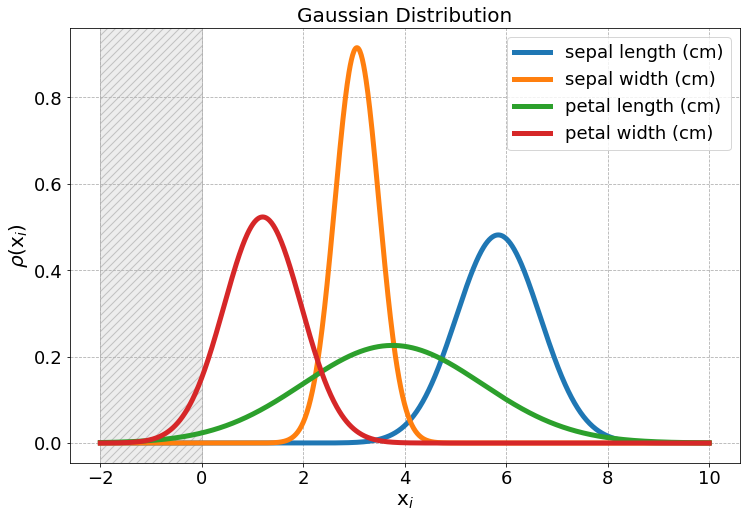

In [5]:
#Creating axes for Gaussian distribution plot
xpdf = np.linspace(-2, 10, 1000)
ypdf = [norm.pdf(xpdf, df.mean()[i], df.std()[i]) for i in range(4)]

# Plot
plt.figure(figsize=(12, 8))

[plt.plot(xpdf, ypdf[i],'-',lw=5,label = iris.feature_names[i]) for i in range(4)]

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.xlabel(r'x$_i$',fontsize=20)
plt.ylabel(r'$\rho$(x$_i$)',fontsize=20)

plt.grid(True, linestyle='--', alpha=1)
plt.axvspan(-2, 0, facecolor='lightgray', alpha=0.4, hatch='///', edgecolor='gray')

plt.title('Gaussian Distribution',fontsize=20)
plt.legend(loc='upper right', fontsize=18)
plt.show()

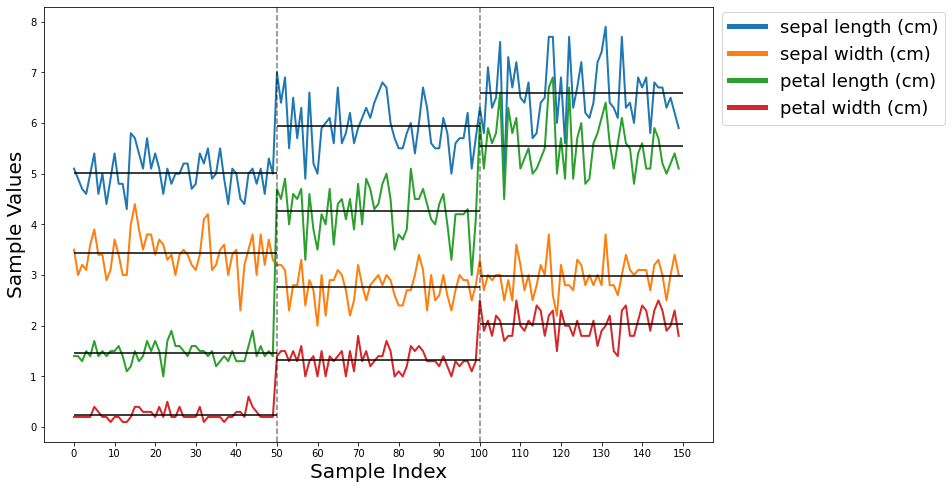

In [6]:
plt.figure(figsize=(12, 8))

[plt.plot(df.T.iloc[i], '-', lw=2,label = iris.feature_names[i]) for i in range(4)]

plt.axvline(x=50, ls='--', c='black', alpha=.5)
plt.axvline(x=100, ls='--', c='black', alpha=.5)

[plt.hlines(slices_mean[0][i],0,50,'black') for i in range(4)]
[plt.hlines(slices_mean[1][i],50,100,'black') for i in range(4)]
[plt.hlines(slices_mean[2][i],100,150,'black') for i in range(4)]

plt.xticks([i for i in range(0,160,10)])
plt.ylabel('Sample Values',fontsize=20)
plt.xlabel('Sample Index',fontsize=20)
leg = plt.legend(bbox_to_anchor=(1.0, 1.01), fontsize=18)
[line.set_linewidth(5) for line in leg.get_lines()]
    
plt.show()

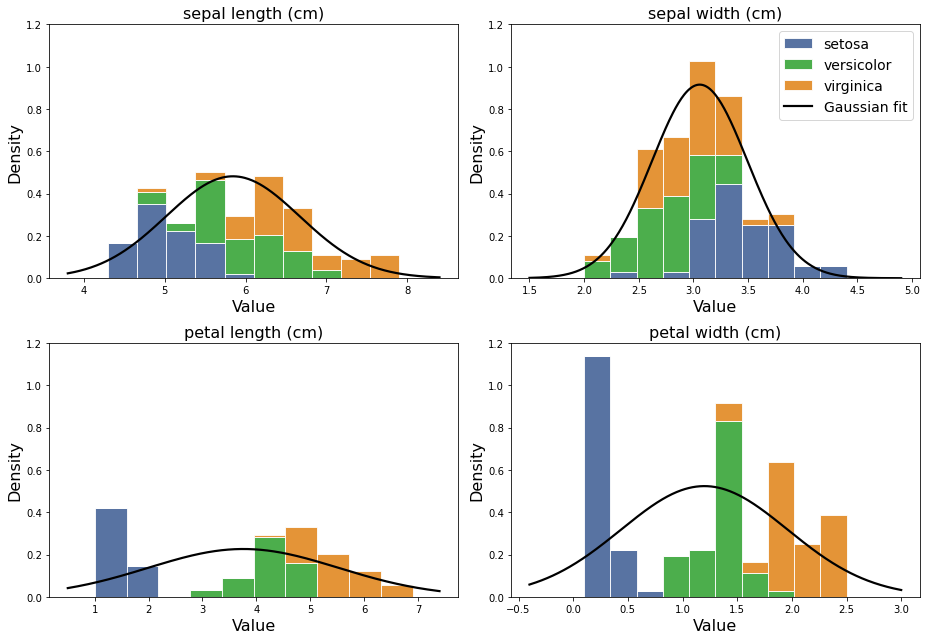

In [7]:
species_colors = ['#3b5b92', '#2ca02c', '#e08214']   # setosa / versicolor / virginica

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for i, ax in enumerate(axes.ravel()):
    mu, sd = df.mean().iloc[i], df.std().iloc[i]
    v = df.iloc[:, i].values
    by_species = [v[iris.target == c] for c in range(3)]        # separa por espécie
    ax.hist(by_species, bins=10, density=True, stacked=True,    # EMPILHADO (estilo do 1º gráfico)
            color=species_colors, edgecolor='white', alpha=.85,
            label=list(iris.target_names))
    x = np.linspace(v.min() - 0.5, v.max() + 0.5, 400)
    ax.plot(x, norm.pdf(x, mu, sd), 'k-', lw=2.2, label='Gaussian fit')
    ax.set_title(iris.feature_names[i], fontsize=16)
    ax.set_ylim(0, 1.2)
    ax.set_xlabel('Value', fontsize=16)
    ax.set_ylabel('Density', fontsize=16)
    if i == 1:
        ax.legend(fontsize=14, loc='upper right')
plt.tight_layout()
plt.show()


## Kernel Density Estimation (KDE)

**KDE** is a *non-parametric* way to estimate the probability density of a variable directly from the data — without assuming a shape. It is the counterpart of fitting a single Gaussian: the Gaussian is *parametric* (you assume a bell curve and only fit its mean and standard deviation), whereas KDE lets the **data decide the shape**.

**Intuition — a smooth histogram.** Instead of dropping each point into a bin and counting, KDE places a small bump (a *kernel*, usually a tiny Gaussian) centred on every data point and sums them. Where points are dense the bumps pile up and the curve rises; where points are sparse it dips. That is why the curve shows *two* humps for the petals — nothing forced it to be unimodal.

**Definition.**
$$
\hat f(x) = \frac{1}{n\,h}\sum_{i=1}^{n} K\!\left(\frac{x - x_i}{h}\right),
$$
where $K$ is the kernel (here a standard normal) and $h$ is the **bandwidth**, which sets how much the estimate is smoothed.

**The bandwidth $h$ is the key knob.**
- small $h$ → spiky curve, one peak per point (overfitting);
- large $h$ → over-smoothed, which can **erase** real structure (e.g. hide bimodality);
- `scipy.stats.gaussian_kde` chooses $h$ automatically (Scott's / Silverman's rule).

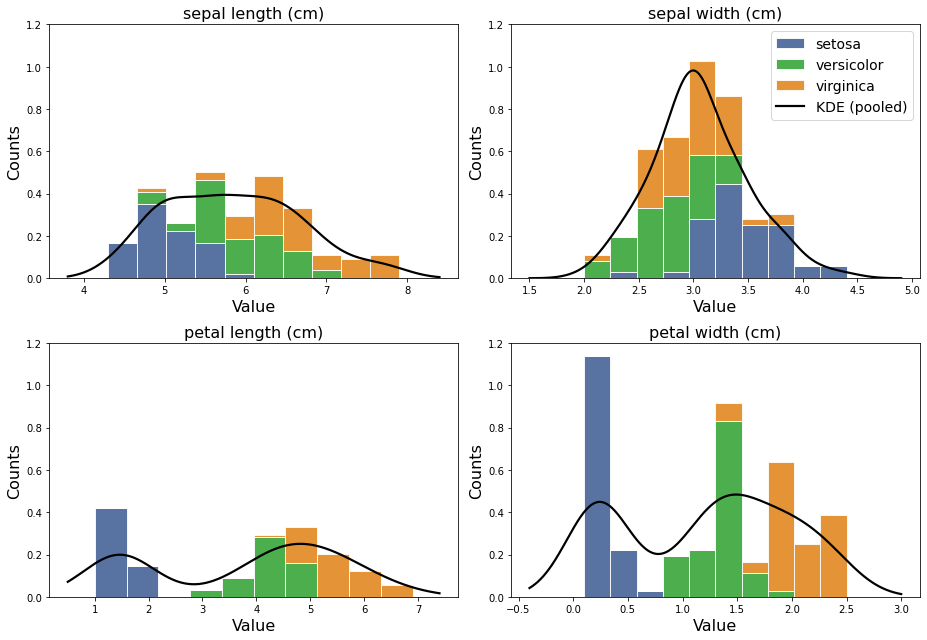

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

species_colors = ['#3b5b92', '#2ca02c', '#e08214']   # setosa / versicolor / virginica

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for i, ax in enumerate(axes.ravel()):
    v = df.iloc[:, i].values
    by_species = [v[iris.target == c] for c in range(3)]        # separa por espécie
    ax.hist(by_species, bins=10, density=True, stacked=True,    # empilhado -> soma = pooled
            color=species_colors, edgecolor='white', alpha=.85,
            label=list(iris.target_names))
    xs = np.linspace(v.min() - 0.5, v.max() + 0.5, 400)
    ax.plot(xs, gaussian_kde(v)(xs), "k-", lw=2.2, label="KDE (pooled)")   # KDE de todas as 150
    ax.set_title(iris.feature_names[i], fontsize=16)
    ax.set_ylim(0, 1.2)
    ax.set_xlabel('Value', fontsize=16)
    ax.set_ylabel('Counts', fontsize=16)
    if i == 1:
        ax.legend(fontsize=14, loc='upper right')
plt.tight_layout()
plt.show()

## Parametric vs. non-parametric models

> **Does the model assume a fixed form or does it let the data dictate the form?**

### Parametric models
A parametric model commits in advance to a functional form described by a
**fixed, finite number of parameters** that does *not* grow with the amount of data.
Learning means estimating those parameters; once fitted, the data can be discarded —
the parameters summarise everything the model knows.

- *Examples:* fitting a Gaussian (just $\mu,\sigma$), linear regression, and **neural networks** (a fixed architecture has a fixed number of weights).
- *Strengths:* data-efficient, fast, compact, interpretable.
- *Weakness:* if the assumed form is wrong, the model stays **biased** no matter how much
  data you give it — e.g. a single Gaussian forced onto the bimodal petal data.

### Non-parametric models
A non-parametric model makes **no fixed assumption about the form**; its flexibility
(its effective number of parameters) **grows with the data**, and often the data itself
is kept and used at prediction time.

- *Examples:* **KDE** (one kernel per data point), $k$-nearest neighbours,
  decision trees / random forests.
- *Strengths:* flexible — captures arbitrary shapes (bimodality, skew, …) with weak assumptions.
- *Weakness:* **data-hungry**, prone to overfitting, heavier to store/evaluate, less interpretable.

### The operational test
> Does the number of parameters stay **fixed** as $n \to \infty$ (parametric)
> or **grow with $n$** (non-parametric)?

*Non-parametric does **not** mean "no parameters."* It means the form is not fixed in advance
and the complexity adapts to the data (KDE still has a bandwidth $h$; trees still have splits).

| | Parametric | Non-parametric |
|---|---|---|
| Form | fixed in advance | learned from data |
| # parameters | fixed | grows with $n$ |
| Assumptions | strong | weak |
| Data needed | less | more |
| Main risk | **bias** (wrong form) | **variance** (overfit) |
| Example here | single Gaussian fit | KDE |

This is exactly the contrast we just saw: the **Gaussian fit** (parametric) imposed a single
bell and missed the structure, while the **KDE** (non-parametric) let the data reveal its two modes.

## 4.1 Clustering with SCALED data

In [9]:
kme = KMeans(n_clusters=3)               # build the k-means model asking for 3 clusters (nothing fitted yet)

kme_labels = kme.fit_predict(iris.data)  # fit k-means and return each sample's cluster label (0/1/2)
kme_coord  = kme.transform(iris.data)    # distance from every sample to each of the 3 centroids → 150×3 matrix

centroids = kme.cluster_centers_         # final centroid coordinates: 3 clusters × 4 features → 3×4 matrix
centroids                                # display the centroids

array([[6.85      , 3.07368421, 5.74210526, 2.07105263],
       [5.006     , 3.428     , 1.462     , 0.246     ],
       [5.9016129 , 2.7483871 , 4.39354839, 1.43387097]])

In [10]:
# build the k-means model asking for 3 clusters (nothing fitted yet)
kme_ss = KMeans(n_clusters=3)

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
iris_ss= scaler.fit_transform(iris.data)
kme_ss_labels= kme_ss.fit_predict(iris_ss)

In [12]:
# final centroid coordinates: 3 clusters × 4 features → 3×4 matrix
centroids = kme_ss.cluster_centers_
centroids

array([[ 1.13597027,  0.08842168,  0.99615451,  1.01752612],
       [-1.01457897,  0.85326268, -1.30498732, -1.25489349],
       [-0.05021989, -0.88337647,  0.34773781,  0.2815273 ]])

In [13]:
n = [i for i in range(1,101)] #change to 14
len(n)

100

In [14]:
import time

kme_inertia = []
kme_ss_iner = [] 
run_time = []

for k in n:
    kme_s = KMeans(n_clusters=k)
    kme_s.fit(iris_ss.data)
    kme_ss_iner.append(kme_s.inertia_)
    kme = KMeans(n_clusters=k)
    kme.fit(iris.data)
    kme_inertia.append(kme.inertia_)

Text(0.5, 1.0, 'Total Dispersion as Cost Function')

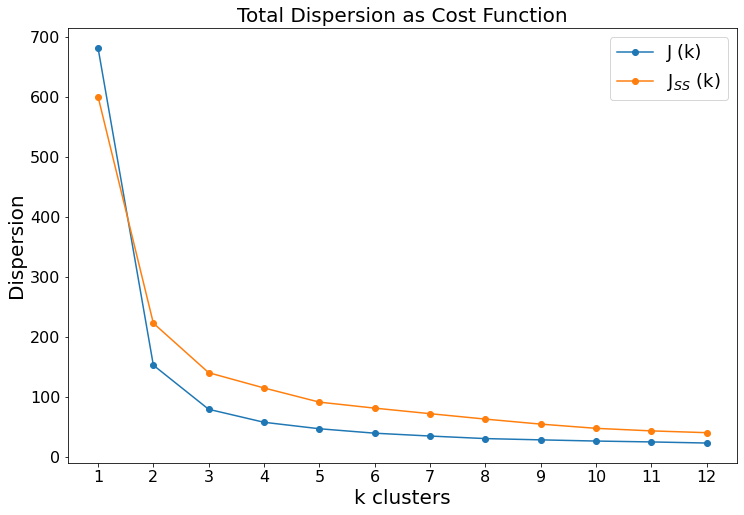

In [15]:
plt.figure(figsize=(12,8))

plt.plot(n[:12], kme_inertia[:12], '-o', label='J (k)')
plt.plot(n[:12], kme_ss_iner[:12], '-o', label='J$_{SS}$ (k)')

plt.xticks(np.arange(1,13, step=1), size=18)
plt.xlabel('k clusters', fontsize=20)
plt.ylabel('Dispersion', fontsize=20)
plt.tick_params(labelsize=16)
plt.legend(fontsize=18, loc='upper right')
plt.title('Total Dispersion as Cost Function', fontsize=20)

Exercise: Do the "maximum curvature" approach from previous session for the scaled dataset.

In [16]:
df_ss = pd.DataFrame(iris_ss)
df_ss.describe()

,0,1,2,3
count,1.500000e+02,1.500000e+02,1.500000e+02,1.500000e+02
mean,-1.690315e-15,-1.842970e-15,-1.698641e-15,-1.409243e-15
std,1.003350e+00,1.003350e+00,1.003350e+00,1.003350e+00
min,-1.870024e+00,-2.433947e+00,-1.567576e+00,-1.447076e+00
25%,-9.006812e-01,-5.923730e-01,-1.226552e+00,-1.183812e+00
50%,-5.250608e-02,-1.319795e-01,3.364776e-01,1.325097e-01
75%,6.745011e-01,5.586108e-01,7.627583e-01,7.906707e-01
max,2.492019e+00,3.090775e+00,1.785832e+00,1.712096e+00


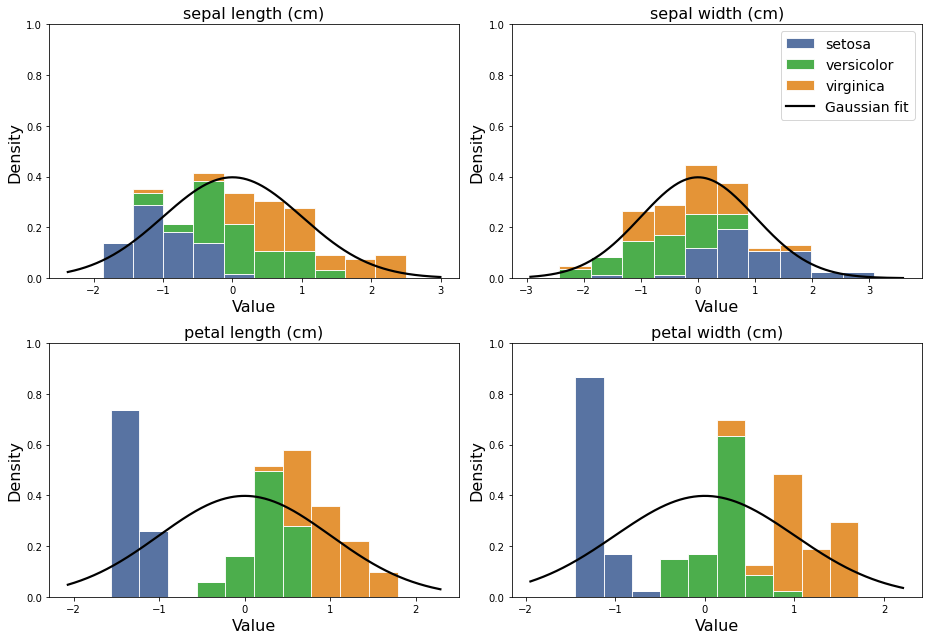

In [17]:
species_colors = ['#3b5b92', '#2ca02c', '#e08214']   # setosa / versicolor / virginica

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for i, ax in enumerate(axes.ravel()):
    mu, sd = df_ss.mean().iloc[i], df_ss.std().iloc[i]
    v = df_ss.iloc[:, i].values
    by_species = [v[iris.target == c] for c in range(3)]        # separa por espécie
    ax.hist(by_species, bins=10, density=True, stacked=True,    # EMPILHADO (estilo do 1º gráfico)
            color=species_colors, edgecolor='white', alpha=.85,
            label=list(iris.target_names))
    x = np.linspace(v.min() - 0.5, v.max() + 0.5, 400)
    ax.plot(x, norm.pdf(x, mu, sd), 'k-', lw=2.2, label='Gaussian fit')
    ax.set_title(iris.feature_names[i], fontsize=16)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Value', fontsize=16)
    ax.set_ylabel('Density', fontsize=16)
    if i == 1:
        ax.legend(fontsize=14, loc='upper right')
plt.tight_layout()
plt.show()


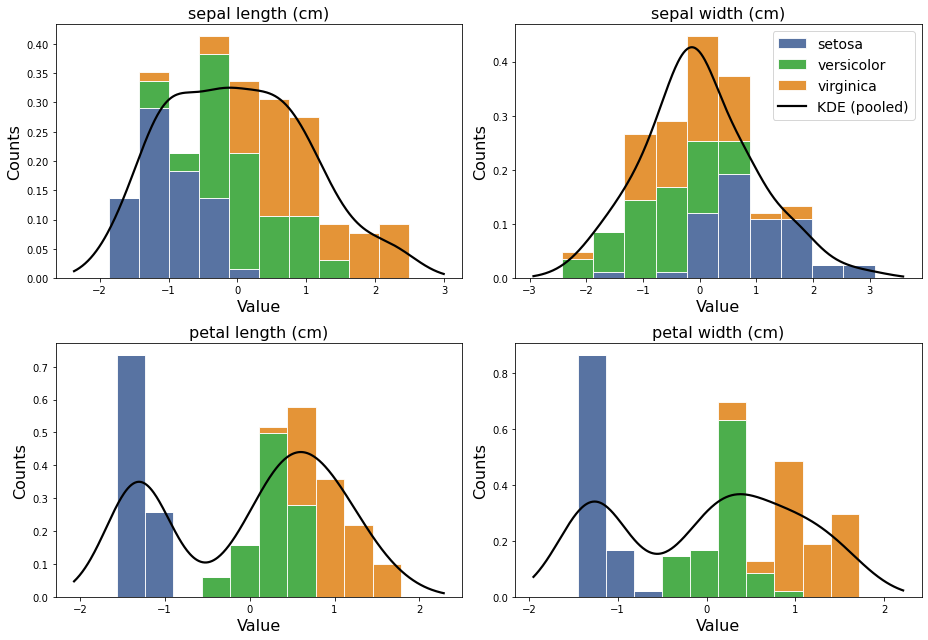

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

species_colors = ['#3b5b92', '#2ca02c', '#e08214']   # setosa / versicolor / virginica

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for i, ax in enumerate(axes.ravel()):
    v = df_ss.iloc[:, i].values
    by_species = [v[iris.target == c] for c in range(3)]        # separa por espécie
    ax.hist(by_species, bins=10, density=True, stacked=True,    # empilhado -> soma = pooled
            color=species_colors, edgecolor='white', alpha=.85,
            label=list(iris.target_names))
    xs = np.linspace(v.min() - 0.5, v.max() + 0.5, 400)
    ax.plot(xs, gaussian_kde(v)(xs), "k-", lw=2.2, label="KDE (pooled)")   # KDE de todas as 150
    ax.set_title(iris.feature_names[i], fontsize=16)
   # ax.set_ylim(0, 1.2)
    ax.set_xlabel('Value', fontsize=16)
    ax.set_ylabel('Counts', fontsize=16)
    if i == 1:
        ax.legend(fontsize=14, loc='upper right')
plt.tight_layout()
plt.show()

## SUPERVISED LEARNING
### TRAIN-TEST Splitting + Ridge Regression Classfier

In [19]:
from sklearn.model_selection import train_test_split

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,        
    random_state=42    
)
print("Training:", X_train.shape, "\nTest:", X_test.shape)
print("\nTraining set:", np.bincount(y_train), "\nTest set:", np.bincount(y_test))

Training: (120, 4) 
Test: (30, 4)

Training set: [40 40 40] 
Test set: [10 10 10]


In [20]:
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

clf = RidgeClassifier()         
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

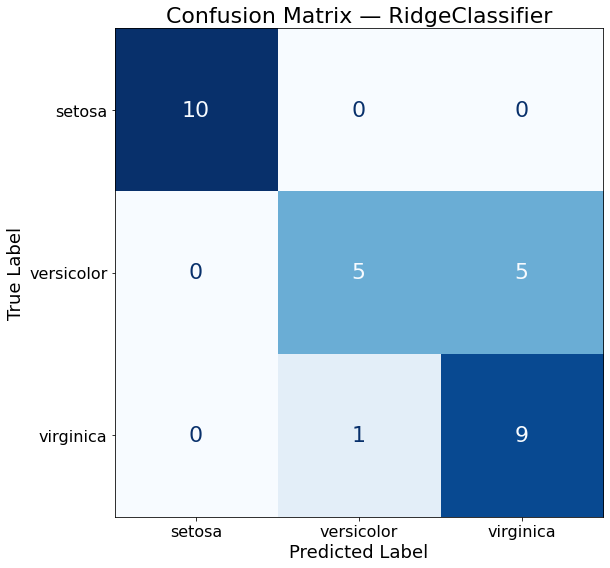

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(12, 8))
disp = ConfusionMatrixDisplay.from_estimator(
    clf, X_test, y_test,
    display_labels=iris.target_names,
    cmap="Blues",
    colorbar=False,
    ax = ax)
[t.set_fontsize(22) for t in disp.text_.ravel()]      
    
ax.set_title("Confusion Matrix — RidgeClassifier", fontsize=22)
ax.set_xlabel('Predicted Label', fontsize=18)
ax.set_ylabel('True Label', fontsize=18)
ax.tick_params(labelsize=16)
plt.tight_layout()
plt.show()

A confusion matrix tabulates true classes (rows) against predicted classes (columns); the diagonal holds correct predictions, off-diagonal entries are errors. Here, setosa is perfect — all 10 correctly classified, none confused (it is linearly separable from the rest). Virginica is strong: 9 of 10 right, 1 misread as versicolor. Versicolor is the weak spot: only 5 of 10 correct, with 5 misclassified as virginica. Overall accuracy is 24/30 = 0.80. The entire error budget sits in the versicolor↔virginica block — exactly the two classes Fisher noted are not linearly separable, which a linear model like RidgeClassifier cannot fully disentangle.

### MNIST: Clustering and Principal Component Analysis (PCA)

**MNIST** (Modified National Institute of Standards and Technology) is the classic benchmark of handwritten digits 0–9. Here we use the lightweight version shipped with scikit-learn, `load_digits`: **1797 images, each an 8×8 grayscale grid → 64 pixels**.

Each image is therefore a single point in a **64-dimensional** space. Two questions drive this section: can k-means *group the digits without ever seeing the labels*, and can we first **compress** those 64 dimensions down to a handful — with **PCA** — while keeping most of the structure?

In [22]:
# the small 8×8 "digits" version of MNIST
from sklearn.datasets import load_digits

In [23]:
mnist = load_digits()        # 1797 handwritten digits, each an 8×8 grayscale image

In [24]:
mnist.keys()                 # what the loaded Bunch object contains

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

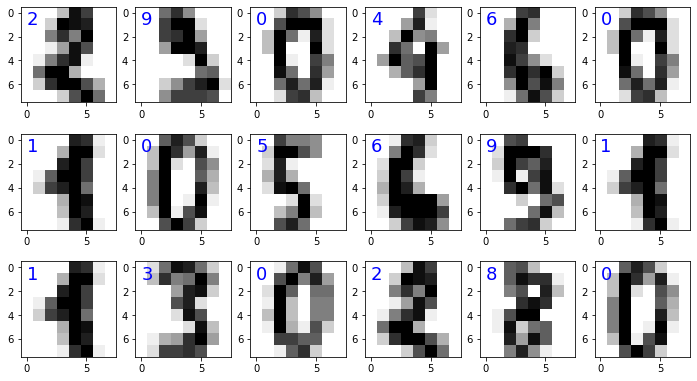

In [25]:
# show 18 random digits together with their true label
plt.figure(figsize=(12,7))
plt.subplots_adjust(wspace=.2,hspace=0.01)

k = np.random.randint(36, size=18)

for i in range(18):
    plt.subplot(3,6,i+1)
    plt.imshow(mnist.images[k[i]],cmap='binary')
    plt.text(0, 1, str(mnist.target[k[i]]), color='blue', fontsize=18)
plt.show()

In [26]:
len(mnist.images)            # how many images in total (1797)

1797

In [27]:
# take the first 1500 images as our working set
X = mnist.data[:1500]        # pixels: each row is a 64-D vector
Y = mnist.target[:1500]      # the true digit (0–9), used only to check the clustering
X.shape, Y.shape

((1500, 64), (1500,))

In [28]:
# stack pixels + label into one table just to inspect the data
x_df = pd.DataFrame(X)
y_df = pd.DataFrame(Y,columns=['digit'])
pd.concat([x_df,y_df],axis=1)

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,digit
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,0.0,0.0,0.0,0.0,6.0,16.0,7.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,8.0,16.0,8.0,0.0,1
1496,0.0,0.0,2.0,13.0,16.0,9.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,16.0,4.0,0.0,0.0,0.0,7
1497,0.0,0.0,0.0,14.0,4.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,13.0,16.0,9.0,0.0,0.0,6
1498,0.0,1.0,9.0,15.0,13.0,4.0,0.0,0.0,0.0,5.0,...,0.0,0.0,0.0,8.0,15.0,16.0,9.0,1.0,0.0,3


### Principal Component Analysis (PCA)

64 dimensions are impossible to visualise and expensive to cluster, yet most of them carry little information — neighbouring pixels are highly correlated. **PCA** finds a new set of orthogonal axes, the **principal components**, ordered so that the first captures the most variance in the data, the second the most of what remains, and so on.

Concretely, the principal components are the **eigenvectors of the covariance matrix** $C$ of the (mean-centred) data, and each eigenvalue $\lambda_i$ is the variance along that axis:
$$C = \tfrac{1}{n}\,X^{\top}X, \qquad C\,v_i = \lambda_i\,v_i .$$
Projecting the data onto the first few eigenvectors gives a low-dimensional view that keeps as much variance as possible. The **explained-variance ratio** $\lambda_i / \sum_j \lambda_j$ tells us how much of the total spread each component accounts for — so we can judge how many components are "enough".

In [29]:
from sklearn.decomposition import PCA

pca = PCA(n_components=10)        # keep the top 5 principal components
pca.fit(X)                      # find the PC axes (eigenvectors of the covariance matrix)
pca_data = pca.transform(X)     # project the 64-pixel images onto those 5 axes → (1500, 5)
pca_data

array([[  1.43756057,  19.83796106, -12.33441198, ...,   2.37369317,
         -0.74601386,  -3.35610909],
       [ -9.72768517, -20.09611466,   7.66242725, ...,  -4.71597382,
          2.8145615 ,   1.91896366],
       [ -8.10665483,  -9.69944815,   4.75794097, ..., -15.75275093,
         -2.59505576,  -4.17512221],
       ...,
       [-12.61727071,  22.2664761 ,   6.75180851, ...,   4.63597091,
         -1.33316843,   0.48267559],
       [ 20.79866557,   2.22120943,   6.18848373, ...,  11.93306365,
         -4.93863659,  -6.61982018],
       [  7.82830522,   1.18612657,  27.87896625, ...,   3.40809449,
          0.54870459,  -9.74137431]])

In [30]:
pca_var = np.round(pca.explained_variance_ratio_* 100, decimals = 2)   # % of variance per PC
pca_var

array([14.84, 13.55, 11.96,  8.6 ,  5.81,  4.95,  4.26,  3.64,  3.29,
        3.03])

In [31]:
# put the projected data in a labelled table: PC_1 … PC_5
labels = ['PC_' + str(x) for x in range(1, len(pca_var)+1)]
pca_df = pd.DataFrame(pca_data, columns=labels)
#pca_df

In [32]:
pca_df.describe()

,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10
count,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03
mean,5.743554e-17,4.363917e-16,-8.834415e-16,9.888386e-16,1.196080e-16,-1.361874e-17,3.446132e-16,5.237292e-16,4.766558e-17,-6.963319e-16
std,1.334991e+01,1.275922e+01,1.198505e+01,1.016260e+01,8.352646e+00,7.710908e+00,7.157132e+00,6.611079e+00,6.282466e+00,6.034154e+00
min,-3.067171e+01,-2.770120e+01,-2.901649e+01,-3.071217e+01,-2.289715e+01,-2.013978e+01,-1.803518e+01,-1.999479e+01,-1.791016e+01,-1.864941e+01
25%,-9.249079e+00,-9.833088e+00,-8.744687e+00,-6.786696e+00,-5.623111e+00,-5.690278e+00,-4.880818e+00,-4.489550e+00,-4.107425e+00,-3.947564e+00
50%,2.340020e-01,-7.761076e-01,-1.349152e+00,8.539986e-01,-7.529552e-01,-2.635662e-01,-6.856092e-01,7.224319e-03,-1.794459e-01,-9.956569e-02
75%,1.041872e+01,9.720067e+00,8.212728e+00,6.966932e+00,4.338656e+00,5.434081e+00,4.108340e+00,4.329912e+00,4.022257e+00,4.082835e+00
max,3.107343e+01,2.998925e+01,3.237202e+01,3.548578e+01,2.762215e+01,2.024681e+01,2.735756e+01,2.204521e+01,2.037496e+01,1.931161e+01


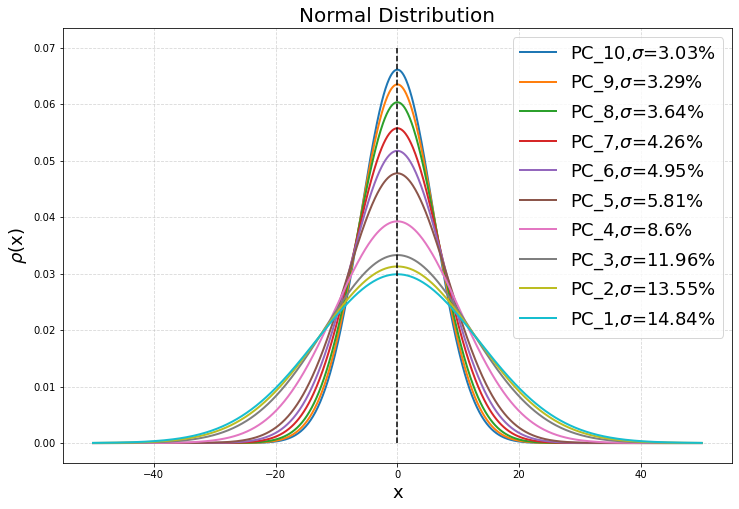

In [33]:
# Gaussian (normal) fit of each principal component
xpdf = np.linspace(-50, 50, 1000)
ypdf = [norm.pdf(xpdf, pca_df.mean().iloc[i], pca_df.std().iloc[i]) for i in range(10)]

# Plot
plt.figure(figsize=(12, 8))
[plt.plot(xpdf, ypdf[9-i],'-',lw=2,
          label = labels[9-i]+',$\sigma$='+str(pca_var[9-i])+'%') for i in range(10)]
plt.vlines(0,0,.07,linestyles='dashed',colors='black')
plt.xlabel('x',fontsize=18)
plt.ylabel(r'$\rho$(x)',fontsize=18)
plt.title('Normal Distribution',fontsize=20)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right', fontsize=18)
plt.show()

In [34]:
pca_v_pair = [j for j in combinations(pca_var, 2)]
pca_pair = [j for j in combinations(labels, 2)]
pca_pair[0]
#pca_df[str(pca_pair[0][1])]

('PC_1', 'PC_2')

Projected onto just the first two principal components, the 64-D images already fall into visibly distinct regions — though some digits (4/9, 3/5/8) overlap, since two axes cannot capture everything. The colour is the *true* digit, used here only to see how well the unsupervised projection lines up with the real classes.

ValueError: x and y must be the same size

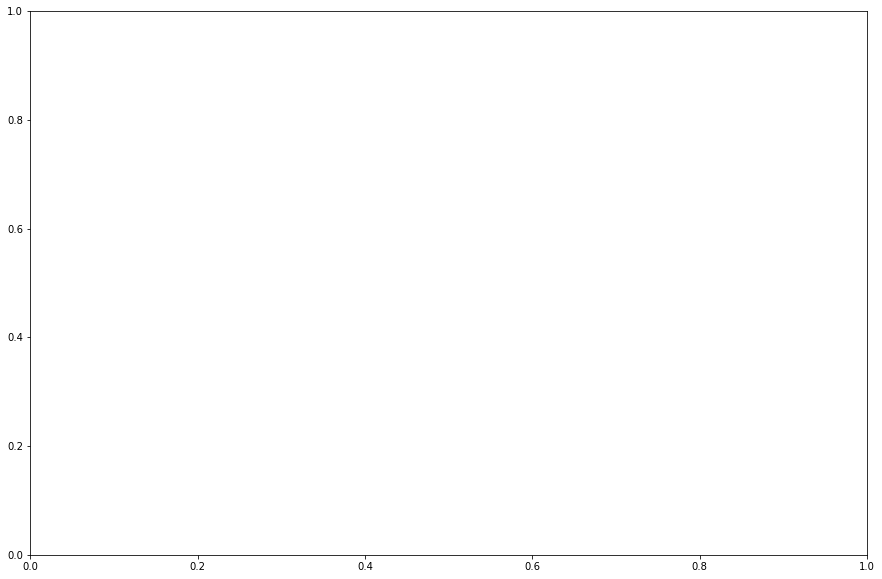

In [35]:
plt.figure(figsize=(15,10))
plt.subplots_adjust(wspace=.2,hspace=.3)

plt.scatter(pca, pca_df[str(pca_pair[0][1])], 
            c=Y, cmap='tab10', alpha=.9, s=100)

plt.xlabel(str(pca_pair[0][0])+': {0}%'.format(pca_v_pair[0][0]), fontsize=16)
plt.ylabel(str(pca_pair[0][1])+': {0}%'.format(pca_v_pair[0][1]), fontsize=16)
plt.axis('equal')
plt.colorbar(label='digit label', ticks=range(10))
    
plt.show()

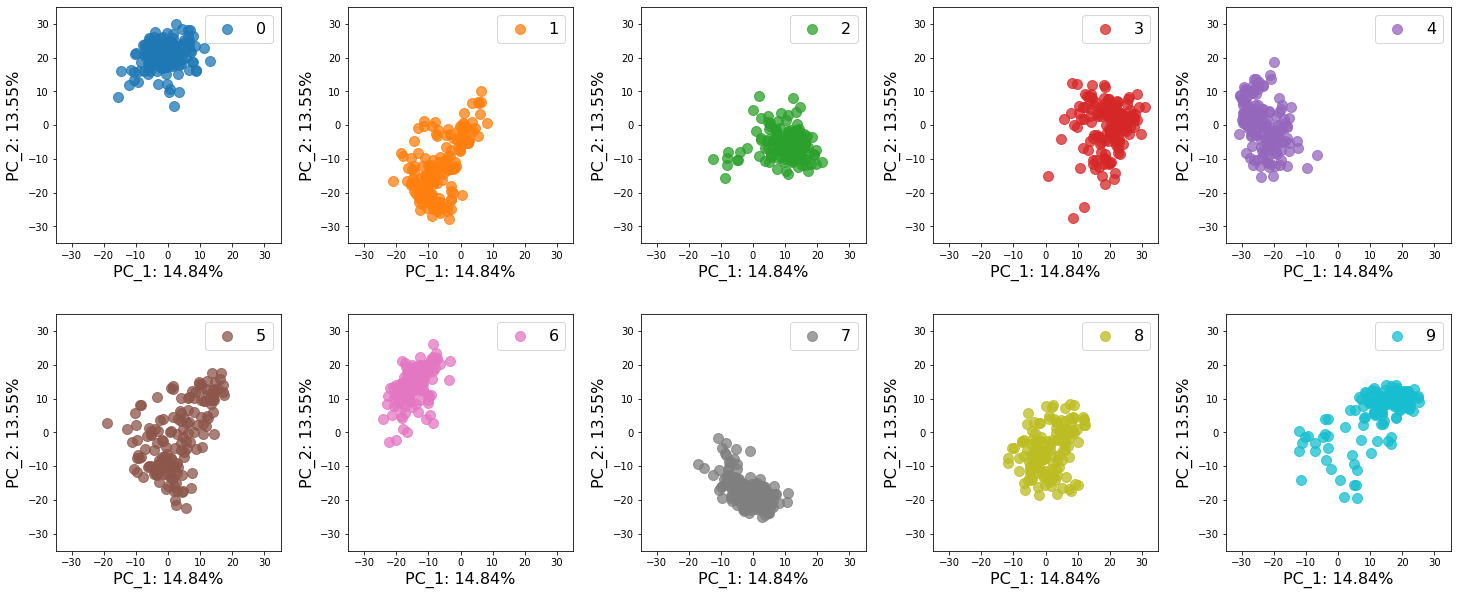

In [36]:
plt.figure(figsize=(25,10))
plt.subplots_adjust(wspace=.3,hspace=.3)

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.scatter(pca_df[str(pca_pair[0][0])][Y==i], pca_df[str(pca_pair[0][1])][Y==i], 
                c='C'+str(i),alpha=.75, s=100, label=i)

    plt.xlabel(str(pca_pair[0][0])+': {0}%'.format(pca_v_pair[0][0]), fontsize=16)
    plt.ylabel(str(pca_pair[0][1])+': {0}%'.format(pca_v_pair[0][1]), fontsize=16)
    plt.xlim(-35,35)
    plt.ylim(-35,35)
    plt.legend(fontsize=16,loc='upper right')
    
plt.show()

### Clustering over *n*  PCA components

Now the real test: run k-means with **k = 10** (one cluster per digit) in the **2-D PCA plane**, and compare the clusters it finds — with no access to the labels — against the true digits. Just like versicolor/virginica in Iris, expect trouble where digits overlap (4/9, 3/5/8): two components and straight Voronoi boundaries cannot separate classes that the projection itself has already mixed together.

In [39]:
from scipy.optimize import linear_sum_assignment

def cluster_pca_plot(X, Y, n_components, pc_x=0, pc_y=1,
                     n_clusters=10, random_state=10, mapping='hungarian'):
    if max(pc_x, pc_y) >= n_components:
        raise ValueError(f"pc_x/pc_y devem ser < n_components ({n_components})")
    # 1) PCA + KMeans
    pca   = PCA(n_components=n_components)
    data  = pca.fit_transform(X)
    km    = KMeans(n_clusters=n_clusters, random_state=random_state)
    label = km.fit_predict(data)
    # 2) cluster mapping -> digit
    if mapping == 'hungarian':
        C = np.zeros((n_clusters, 10), dtype=int)
        for cl, dg in zip(label, Y):
            C[cl, dg] += 1
        row, col = linear_sum_assignment(-C)
        cluster_to_digit = dict(zip(row, col))
        labels_mapped = np.array([cluster_to_digit[cl] for cl in label])
    elif mapping == 'majority':
        labels_mapped = np.zeros_like(label)
        for c in np.unique(label):
            m = (label == c)
            labels_mapped[m] = np.bincount(Y[m]).argmax()
    else:
        raise ValueError("mapping deve ser 'hungarian' ou 'majority'")
    acc = (labels_mapped == Y).mean()
    # 3) plot: real | mapped | correct
    var = pca.explained_variance_ratio_ * 100
    fig, ax = plt.subplots(1, 3, figsize=(32, 10))
    ax[0].scatter(data[:, pc_x], data[:, pc_y],
                  c=label, cmap='tab10', vmin=-0.5, vmax=9.5, alpha=.75, s=50)
    ax[0].set_title("K-Means (raw cluster id)", fontsize=20)
    ax[1].scatter(data[:, pc_x], data[:, pc_y],
                  c=labels_mapped, cmap='tab10', vmin=-0.5, vmax=9.5, alpha=.75, s=50)
    ax[1].set_title(f"K-Means ({mapping}) — acc={acc*100:.1f}%", fontsize=20)
    sc = ax[2].scatter(data[:, pc_x], data[:, pc_y],
                       c=Y, cmap='tab10', vmin=-0.5, vmax=9.5, alpha=.75, s=50)
    ax[2].set_title("Correct Labels", fontsize=20)
    for a in ax:
        a.set_xlabel(f'PC{pc_x+1}: {var[pc_x]:.1f}%', fontsize=18)
        a.set_ylabel(f'PC{pc_y+1}: {var[pc_y]:.1f}%', fontsize=18)
    fig.colorbar(sc, ax=ax, ticks=range(10), label='digit')
    plt.show()
    return pca, km, label, labels_mapped, acc

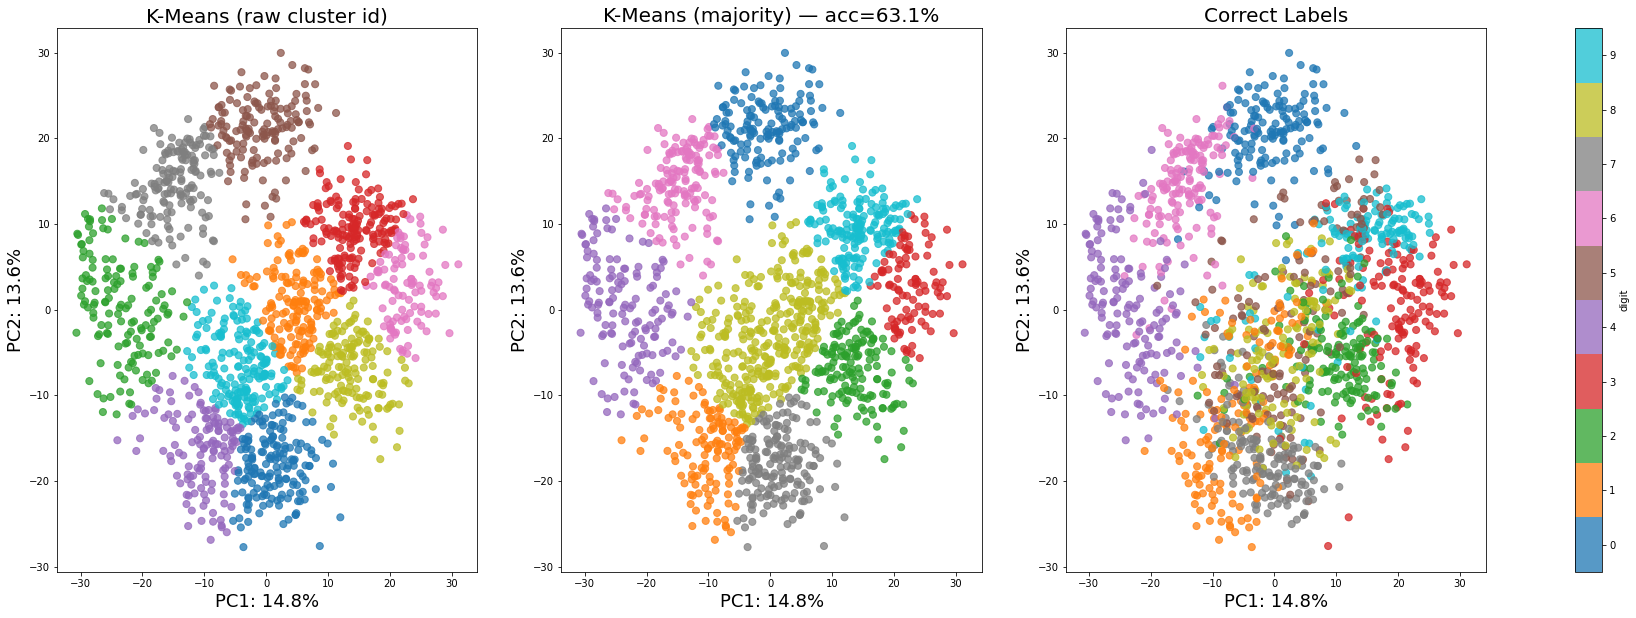

acc = 63.1%


In [40]:
pca, km, label, labels_mapped, acc = cluster_pca_plot(X=X, Y=Y, n_components=2, mapping='majority')
print(f"acc = {acc*100:.1f}%")

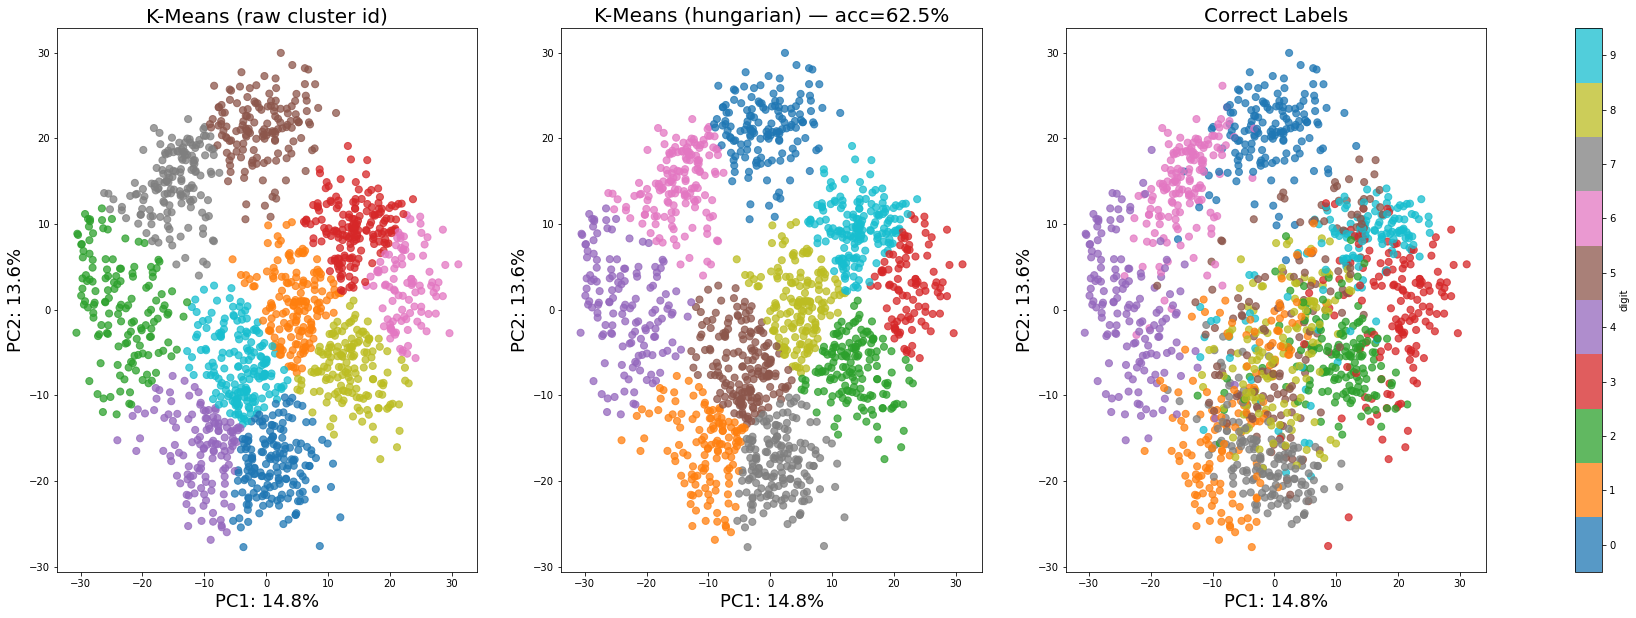

acc = 62.5%


In [41]:
pca, km, label, labels_mapped, acc = cluster_pca_plot(X=X, Y=Y, n_components=2, mapping='hungarian')
print(f"acc = {acc*100:.1f}%")

## Naming the clusters: Majority vote vs. Hungarian

K-means produces **anonymous groups** — cluster `0`, `1`, `2`, … — whose numbers come from random initialization, **not** from the real digits. Cluster `3` is *not* digit 3. To compare the clustering against the true labels (accuracy, confusion matrix), we first need to decide *which real digit each cluster corresponds to*. There are two ways to do this.

### Majority vote
Look at **one cluster at a time** and ask: *"Which digit appears most often inside it?"* Label the whole cluster with that digit.

- Simple and local — each cluster decides on its own.
- **Many-to-one:** two clusters can pick the same digit, leaving another digit with **no cluster at all** — it disappears from the plot.
- The accuracy it reports measures **purity**, and tends to *inflate* (several clusters can pile onto the same digit).

### Hungarian (optimal assignment)
Look at **all clusters and all digits together** and ask: *"What pairing gives the most correct labels overall?"* Solved with `scipy.optimize.linear_sum_assignment`.

- **One-to-one bijection:** each cluster gets one digit, each digit gets one cluster.
- **No digit is ever left out.**
- The accuracy it reports is the **honest clustering accuracy**, bounded by the real quality of the clusters.

### The analogy — 10 students, 10 desks
- **Majority:** each student runs to their favorite desk → two may fight over the same one, leaving a desk empty.
- **Hungarian:** a teacher seats everyone at once so all 10 desks are filled and total happiness is highest.

### Which to use
| Goal | Method |
|:---|:---|
| Measure how **pure** each cluster is | Majority |
| **Compare to true labels** fairly, never lose a digit | Hungarian |

> **Important:** neither method changes the clustering itself — the true labels are used *only after* k-means, to name the groups and score them. The labels never influence how the clusters are formed.

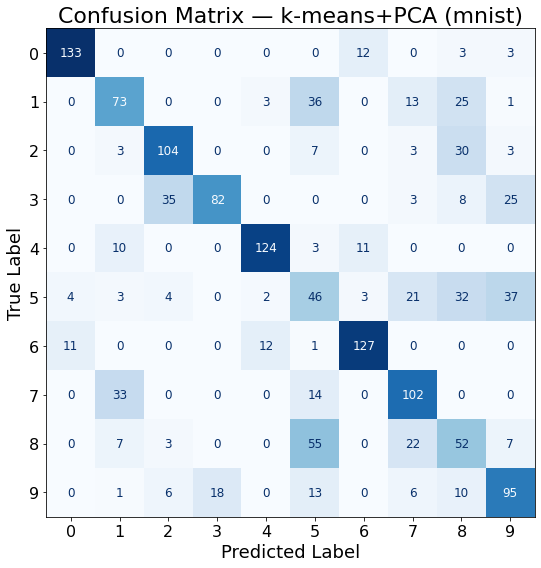

In [42]:
#import numpy as np
#import matplotlib.pyplot as plt
#from sklearn.metrics import ConfusionMatrixDisplay   

fig, ax = plt.subplots(figsize=(12, 8))
disp = ConfusionMatrixDisplay.from_predictions(
    Y, labels_mapped,#pca_kmeans_mnist[2],                           
    display_labels=np.arange(10),
    cmap="Blues",
    colorbar=False,
    ax=ax)
[t.set_fontsize(12) for t in disp.text_.ravel()]

ax.set_title("Confusion Matrix — k-means+PCA (mnist)", fontsize=22)
ax.set_xlabel('Predicted Label', fontsize=18)
ax.set_ylabel('True Label', fontsize=18)
ax.tick_params(labelsize=16)
plt.tight_layout()
plt.show()

#print("Accuracy:", int((Y == mapped).sum()), "out of", len(Y), f'=> {acc:.2f}%')

$\sqrt{X^2 + Z^3}$

## Day 3 - SUPERVISED LEARNING: 
## Classification 

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import preprocessing
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore", category=Warning)

import tensorflow as tf
(train_X,train_y),(test_X,test_y) = tf.keras.datasets.mnist.load_data(path='mnist.npz')

In [55]:
#### sanity check
print('X_train: ' + str(train_X.shape))
print('Y_train: ' + str(train_y.shape))
print('X_test:  '  + str(test_X.shape))
print('Y_test:  '  + str(test_y.shape))
#### sanity check

X_train: (60000, 28, 28)
Y_train: (60000,)
X_test:  (10000, 28, 28)
Y_test:  (10000,)


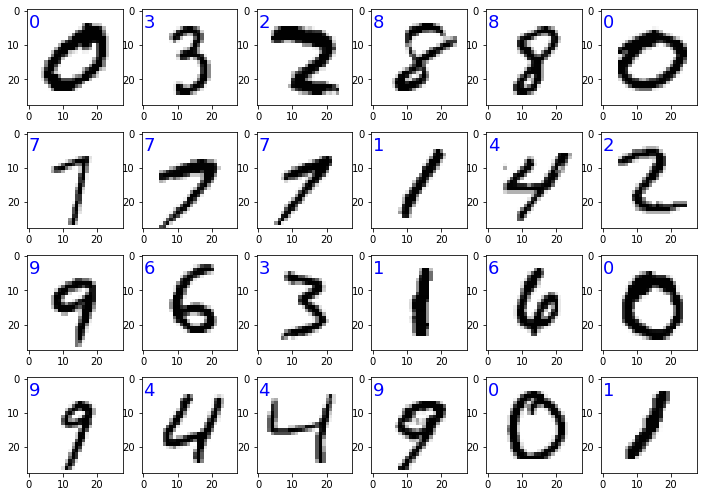

In [57]:
plt.figure(figsize=(12,9))
plt.subplots_adjust(wspace=.2,hspace=0.01)

k = np.random.randint(150, size=24)

for i in range(24):
    plt.subplot(4,6,i+1)
    plt.imshow(train_X[k[i]],cmap='binary')
    plt.text(0, 5, train_y[k[i]], color='blue', fontsize=18)
plt.show()

In [59]:
#reshaping X into a 2D array for PCA 
X_train = train_X.reshape(len(train_X), -1) 
y_train = train_y
X_test  = test_X.reshape(len(test_X), -1) 
y_test  = test_y 

#### sanity check
print('X_train: ' + str(X_train.shape))
print('Y_train: ' + str(y_train.shape))
print('X_test:  '  + str(X_test.shape))
print('Y_test:  '  + str(y_test.shape))
#### sanity check

X_train: (60000, 784)
Y_train: (60000,)
X_test:  (10000, 784)
Y_test:  (10000,)


In [60]:
import time

from sklearn.linear_model import RidgeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

In [67]:
s_methods = [RidgeClassifier,
             LogisticRegression,
             RandomForestClassifier,
            ]

In [68]:
def supervised(s):
    
    start = 0
    end   = 0
    
    method = s()
    start = time.process_time()
    method.fit(X_train,y_train)
    y_pred = method.predict(X_train)
    end = time.process_time()
    score = accuracy_score(y_train, y_pred)
    print(str(method)+' SCORE: '+str(score)+'; TIME: '+str(round(end-start, 1))+'s')
    
    return y_pred

In [69]:
y_pred = [supervised(i) for i in s_methods]

RidgeClassifier() SCORE: 0.8577333333333333; TIME: 2.2s
LogisticRegression() SCORE: 0.9339166666666666; TIME: 53.3s
RandomForestClassifier() SCORE: 1.0; TIME: 51.5s


In [71]:
[print(confusion_matrix(y_train, y_pred[i])) for i in [0,1,2]]

[[5682    7   18   14   24   43   64    4   61    6]
 [   2 6548   40   15   19   31   14   12   55    6]
 [  99  264 4792  149  108   11  234   91  192   18]
 [  42  167  176 5158   32  125   56  115  135  125]
 [  10   99   42    6 5212   50   39   23   59  302]
 [ 164   95   28  432  105 3991  192   36  235  143]
 [ 108   74   61    1   70   90 5476    0   35    3]
 [  55  189   37   47  170    9    2 5426   10  320]
 [  75  493   63  226  105  221   56   20 4412  180]
 [  68   60   20  117  371   12    4  492   38 4767]]
[[5764    0   15    9   14   36   33   10   38    4]
 [   1 6584   32   19    6   20    3   10   55   12]
 [  28   47 5445   89   61   20   56   51  140   21]
 [  17   23  118 5582    6  162   14   50  119   40]
 [  13   22   23    9 5491    8   48   15   42  171]
 [  57   18   40  161   48 4793   82   15  160   47]
 [  34    9   40    0   35   58 5713    4   21    4]
 [  11   20   58   28   42    8    4 5896   20  178]
 [  27   93   55  122   19  136   36   18 529

[None, None, None]

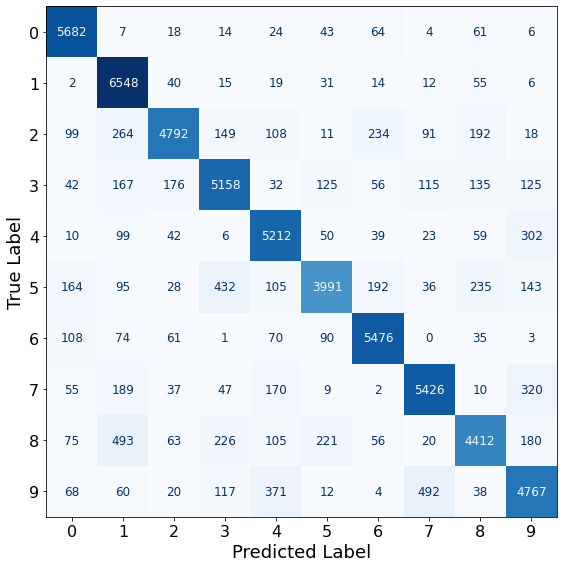

In [77]:
fig, ax = plt.subplots(figsize=(12, 8))
disp = ConfusionMatrixDisplay.from_predictions(
    y_train, y_pred[0],#pca_kmeans_mnist[2],                           
    display_labels=np.arange(10),
    cmap="Blues",
    colorbar=False,
    ax=ax)
[t.set_fontsize(12) for t in disp.text_.ravel()]

ax.set_xlabel('Predicted Label', fontsize=18)
ax.set_ylabel('True Label', fontsize=18)
ax.tick_params(labelsize=16)
plt.tight_layout()
plt.show()

In [83]:
k_fixed = np.array([113, 384, 297,  39, 385,  64,
                    414, 228, 442, 959, 392, 667,
                    999, 751, 367, 647, 544, 876,
                    246, 100, 477, 103, 216, 120,
                    680, 883, 464, 914, 773, 544,
                    927, 954, 263, 458, 169, 854])

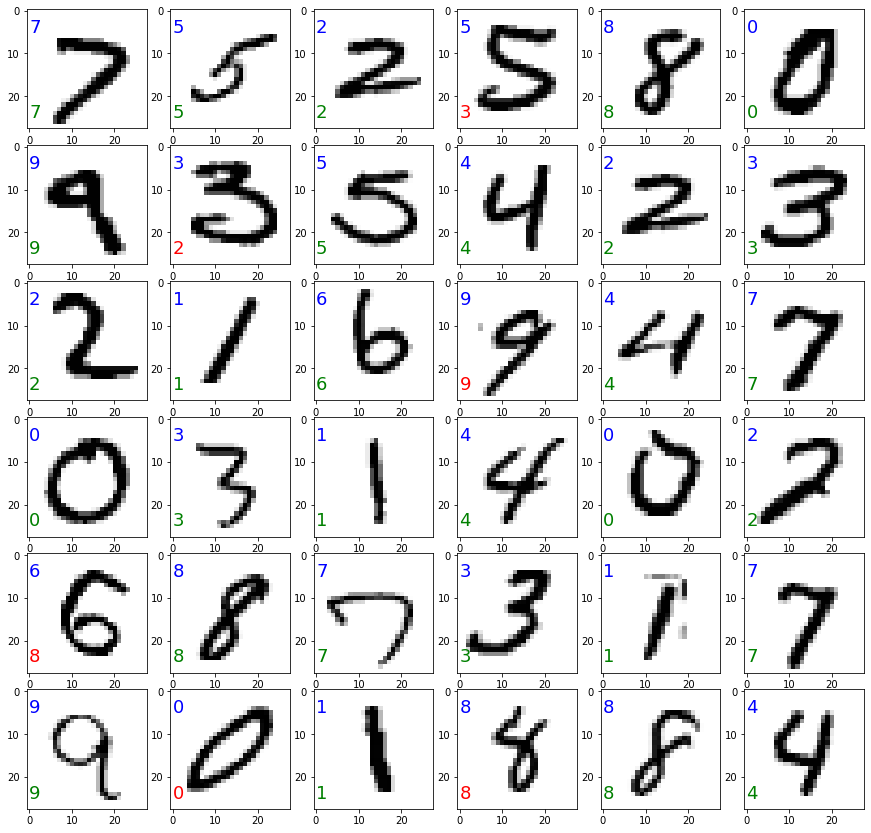

In [93]:
plt.figure(figsize=(15,15))
plt.subplots_adjust(wspace=.2,hspace=0.01)

#k = k_fixed
k = np.random.randint(1000, size=36)

for i in range(36):
    plt.subplot(6,6,i+1)
    plt.imshow(train_X[k[i]], cmap='binary')
    plt.text(0, 5, y_train[k[i]], fontsize=18, color='blue')
    plt.text(0, 25, y_pred[1][k[i]], fontsize=18,
             color='green' if (y_train[k[i]] == y_pred[0][k[i]]) else 'red')
plt.show()

## SUPERVISED LEARNING: 
### Regression 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Loading Dataset

In [ ]:
cp_data = pd.read_csv('cp_data_demo.csv')
cp_data

In [ ]:
cp_data = cp_data.rename(
            columns={"CONDITION: Temperature (K)":"T (K)",
                    "PROPERTY: Heat Capacity (J/mol K)":"Cp (J/molK)"})

In [ ]:
cp_data.shape

In [ ]:
cp_data.head()

In [ ]:
k = sorted(np.random.randint(4500, size=10))

In [ ]:
cp_data.iloc[k]

## Data Cleaning

In [ ]:
#dropping NaN values
cp_data_1 = cp_data.dropna(axis=0, how='any')
cp_data_1.shape

In [ ]:
#searching negative Temperatures
cp_data_1.loc[cp_data_1['T (K)'] < 0]

In [ ]:
negative_T = (cp_data_1.loc[cp_data_1['T (K)'] < 0]).index
negative_T

In [ ]:
#searching negative Heat_Cap
cp_data_1.loc[cp_data_1['Cp (J/molK)'] < 0]

In [ ]:
negative_Cp = (cp_data_1.loc[cp_data_1['Cp (J/molK)'] < 0]).index
negative_Cp

In [ ]:
#cleaning Negative Temperatures
cp_data_2 = cp_data_1.drop(negative_T, axis=0)
cp_data_2.shape

In [ ]:
#cleaning Negative Heat_Cap
cp_data_3 = cp_data_2.drop(negative_Cp, axis=0)
cp_data_3.shape

In [ ]:
#!careful with leaking data between datasets
formula = cp_data_3['FORMULA'].unique()
len(formula)

In [ ]:
formula

In [ ]:
valid_samples = int(round(.2*len(formula)))
test_samples = int(round(.1*len(formula)))
train_samples = len(formula)-test_samples-valid_samples

In [ ]:
train_samples, valid_samples, test_samples

In [ ]:
# Set a random seed
RNG_SEED = 42
np.random.seed(seed=RNG_SEED)

all_f = formula.copy()
valid_data = np.random.choice(all_f,
                              size=valid_samples,
                              replace=False)

all_f = [ f for f in all_f if f not in valid_data]
test_data = np.random.choice(all_f,
                              size=test_samples,
                              replace=False)

all_f = [ f for f in all_f if f not in test_data]
train_data = all_f.copy()

In [ ]:
cp_train = cp_data_3.loc[cp_data_3['FORMULA'].isin(train_data)]
cp_train.shape

In [ ]:
cp_valid = cp_data_3.loc[cp_data_3['FORMULA'].isin(valid_data)]
cp_valid.shape

In [ ]:
cp_test = cp_data_3.loc[cp_data_3['FORMULA'].isin(test_data)]
cp_test.shape

In [ ]:
cp_train.head()

In [ ]:
cp_valid.head()

In [ ]:
cp_test.head()

## Data Featurization

### Sub-sampling

In [ ]:
cp_train_sample = cp_train.sample(n=2000, random_state=RNG_SEED)
cp_valid_sample = cp_valid.sample(n=200, random_state=RNG_SEED)
cp_test_sample = cp_test.sample(n=200, random_state=RNG_SEED)

len(cp_train_sample),len(cp_valid_sample),len(cp_test_sample)

### Generate features using CBFV package

In [ ]:
from cbfv.cbfv.composition import generate_features

In [ ]:
elements = pd.read_csv('cbfv/element_properties/oliynyk.csv')

In [ ]:
len(elements.columns.values)

In [ ]:
elements.columns.values

In [ ]:
rename_dict = {'FORMULA':'formula','T (K)':'T',
               'Cp (J/molK)':'target'}
cp_train_sample = cp_train_sample.rename(columns=rename_dict)
cp_valid_sample = cp_valid_sample.rename(columns=rename_dict)
cp_test_sample = cp_test_sample.rename(columns=rename_dict)

In [ ]:
X_train_unscaled, y_train, formula_train, skipped_train = generate_features(
    cp_train_sample,
    elem_prop='oliynyk', 
    drop_duplicates=False, 
    extend_features=True, 
    sum_feat=True)

X_valid_unscaled, y_valid, formula_valid, skipped_valid = generate_features(
    cp_valid_sample, 
    elem_prop='oliynyk', 
    drop_duplicates=False, 
    extend_features=True, 
    sum_feat=True)

X_test_unscaled, y_test, formula_test, skipped_test = generate_features(
    cp_test_sample, 
    elem_prop='oliynyk', 
    drop_duplicates=False, 
    extend_features=True, 
    sum_feat=True)

In [ ]:
len(X_train_unscaled.columns.values)

In [ ]:
X_train_unscaled.columns.values

### Scaler and Normalizer

In [ ]:
from sklearn.preprocessing import normalize
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [ ]:
X_train = scaler.fit_transform(X_train_unscaled)
X_valid = scaler.fit_transform(X_valid_unscaled)
X_test  = scaler.fit_transform(X_test_unscaled)

In [ ]:
X_train_unscaled.describe()

In [ ]:
X_train_unscaled['sum_Atomic_Weight'].describe()

In [ ]:
from scipy.stats import norm
# Creating axes for Gaussian distribution plot
xpdf = np.linspace(-200, 500, 100)
ypdf = [norm.pdf(xpdf,
                 X_train_unscaled['sum_Atomic_Weight'].mean(),
                 X_train_unscaled['sum_Atomic_Weight'].std()),
        norm.pdf(xpdf,
                 X_train_unscaled['sum_Atomic_Number'].mean(),
                 X_train_unscaled['sum_Atomic_Number'].std())
       ]
       

# Plot
plt.figure(figsize=(10, 6))
[plt.plot(xpdf, ypdf[i],'-',lw=2,label=X_train_unscaled.columns[i]) for i in range(2)]
plt.vlines(X_train_unscaled['sum_Atomic_Weight'].mean(),0,.0035,linestyles='dashed',colors='black')
plt.vlines(X_train_unscaled['sum_Atomic_Number'].mean(),0,.0085,linestyles='dashed',colors='black')
plt.xlabel('x',fontsize=16)
plt.ylabel(r'$\rho$(x)',fontsize=16)
plt.title('(!)Gausssian(!) Distribution',fontsize=16)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right', fontsize=14)
plt.show()

In [ ]:
xpdf = np.linspace(-5, 5, 100)
ypdf = [norm.pdf(xpdf,
                 X_train[1].mean(),
                 X_train[1].std()),
        norm.pdf(xpdf,
                 X_train[0].mean(),
                 X_train[0].std())
       ]
       

# Plot
plt.figure(figsize=(10, 6))
[plt.plot(xpdf, ypdf[i],'-',lw=2,label=X_train_unscaled.columns[i]) for i in range(2)]
plt.vlines(0,0,.4,linestyles='dashed',colors='black')
plt.xlabel('x',fontsize=16)
plt.ylabel(r'$\rho$(x)',fontsize=16)
plt.title('... Distribution',fontsize=16)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right', fontsize=14)
plt.show()

In [ ]:
X_train = normalize(X_train)
X_valid = normalize(X_valid)
X_test = normalize(X_test)

In [ ]:
xpdf = np.linspace(-.25, .25, 100)
ypdf = [norm.pdf(xpdf,
                 X_train[1].mean(),
                 X_train[1].std()),
        norm.pdf(xpdf,
                 X_train[0].mean(),
                 X_train[0].std())
       ]
       

# Plot
plt.figure(figsize=(10, 6))
[plt.plot(xpdf, ypdf[i],'-',lw=2,label=X_train_unscaled.columns[i]) for i in range(2)]
plt.vlines(0,0,5,linestyles='dashed',colors='black')
plt.xlabel('x',fontsize=16)
plt.ylabel(r'$\rho$(x)',fontsize=16)
plt.title('... Distribution',fontsize=16)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right', fontsize=14)
plt.show()

### Supervised Learning Models: Regression

In [ ]:
from time import time

### methods
from sklearn.dummy import DummyRegressor

from sklearn.linear_model import Ridge

from sklearn.neighbors import KNeighborsRegressor

from sklearn.svm import SVR
from sklearn.svm import LinearSVR

from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import RandomForestRegressor

### metrics

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [ ]:
nine_methods = [DummyRegressor,
                Ridge,
                KNeighborsRegressor,
                SVR,
                LinearSVR,
                AdaBoostRegressor,
                GradientBoostingRegressor,
                ExtraTreesRegressor,
                RandomForestRegressor
               ]

In [ ]:
nine_methods[1]

In [ ]:
### Measurements

def meas_method (act, pred):
    r2   = r2_score(act, pred)
    mae  = mean_absolute_error(act,pred)
    rmse = mean_squared_error(act,pred)#squared=False)
    
    return r2, mae, rmse

In [ ]:
###Define plot + regression y_pred

def plot_method (act, pred, method):
    xy_max = np.max([np.max(act), np.max(pred)])
    polyfit = np.polyfit(act,pred,deg=1)
    reg_lsp = np.poly1d(polyfit)
    
    #print (reg_lsp, reg_lsp[1])
   
    line = [ i for i in range(0,int(xy_max)+20,20)]
    reg_lsm = reg_lsp(line)
    
    plt.plot(act,pred, 'o', ms=9, mec= 'k', mfc= 'silver', alpha=.4)
    plt.plot([0,xy_max],[0,xy_max],'k--', label='Target')
    plt.plot(line,reg_lsm,'r-', label ='Linear fit')#+str(reg_lsp))   
    
    plt.xlabel(r'Actual C$_{p}$',fontsize=14)
    plt.ylabel(r'Predicted C$_{p}$',fontsize=14)
    plt.legend(loc='upper left',fontsize=12)
    plt.title(str(method.__name__)+
              ',  r2_score = '+ '{:0.4f}'.format(r2_score(act,pred))
              ,fontsize=16)
    #plt.show()
    return f'{reg_lsp[1]:0.6f}'

In [ ]:
###Evaluate
def evaluate (X_train, y_train, X_valid, y_valid, methods):
    
    fit_time   = []
    meas_train = []
    meas_valid = []
    pred_valid = []
    for m in methods:
    
        method =m()
        start = time()
        method.fit(X_train, y_train)
        end = time()
        delta = end-start
        print(m.__name__, '{:0.4f}'.format(delta)+'s')
        y_pred_t = method.predict(X_train)
        y_pred_v = method.predict(X_valid)
        
        fit_time.append(delta)
        pred_valid.append(y_pred_v)
        meas_train.append(meas_method(y_train,y_pred_t))
        meas_valid.append(meas_method(y_valid,y_pred_v))
    
    
    return meas_train, meas_valid, pred_valid, fit_time

In [ ]:
e = evaluate(X_train,y_train,X_valid, y_valid,nine_methods)

In [ ]:
e_five = plot_method (y_valid,e[2][1],nine_methods[1])

In [ ]:
plt.figure(figsize=(20,20))
plt.subplots_adjust(wspace=.2,hspace=.2)

e_five =[]

for j in range(0,9):
    plt.subplot(3,3,j+1)
    e_five.append(plot_method (y_valid,e[2][j],nine_methods[j]))
    
plt.savefig('nine_ML_methods.png')

### Methods Performance

In [ ]:
meas_train = e[0]
meas_valid = e[1]
time_fitti = e[3]

In [ ]:
df_time = pd.DataFrame(time_fitti, columns=['Fitting time'],
                       index=[m.__name__ for m in nine_methods])

df_train = pd.DataFrame(meas_train, 
                        columns=['r2_score_train', 'mae_train', 'rmse_train'],
                        index=[m.__name__ for m in nine_methods])

df_coef = pd.DataFrame(e_five, columns=['coef.lin_valid'],
                       index=[m.__name__ for m in nine_methods])

df_valid = pd.DataFrame(meas_valid, 
                   columns=['r2_score_valid', 'mae_valid', 'rmse_valid'], 
                   index=[m.__name__ for m in nine_methods])

df = pd.concat([df_time,df_train,df_valid,df_coef], axis=1)
df = df.sort_values('r2_score_valid')


In [ ]:
def highlight_cols(x): 
      
    # copy df to new - original data is not changed 
    df = x.copy() 
      
    # select all values to green color 
    df.loc[:, :] = 'background-color: white and silver'
      
    # overwrite values grey color 
    df['r2_score_valid'] = 'background-color: lightgrey'
      
    # return color df 
    return df  
  
df_highlight = df.style.apply(highlight_cols, axis = None)

In [ ]:
df_highlight